In [19]:
import os
import pandas as pd
import numpy as np
import re
from scipy.stats import gmean
import matplotlib.pyplot as plt

In [5]:
# Sets the path to the parent directory of RR classes
os.chdir("C:/Users/ydmar/repositories/RRcourse2026")

In [ ]:
# Import data from the O*NET database, at ISCO-08 occupation level.
# The original data uses a version of SOC classification, but the data we load here
# are already cross-walked to ISCO-08 using: https://ibs.org.pl/en/resources/occupation-classifications-crosswalks-from-onet-soc-to-isco/

# The O*NET database contains information for occupations in the USA, including
# the tasks and activities typically associated with a specific occupation.

# isco08 variable is for occupation codes
# the t_* variables are specific tasks conducted on the job
# read employment data from Eurostat
# These datasets include quarterly information on the number of workers in specific
# 1-digit ISCO occupation categories. (Check here for details: https://www.ilo.org/public/english/bureau/stat/isco/isco08/)
# We will focus on three countries, but perhaps we could clean this code to allow it
# to easily run for all the countries in the sample?

# This will calculate worker totals in each of the chosen countries.

DATA_PATH = "Data"
FILE_NAME = "Eurostat_employment_isco.xlsx"
COUNTRIES = ["Belgium", "Spain", "Poland"]
ISCO_NUMBERS = range(1, 10)  

def load_and_calculate_totals(file_path, countries, isco_range):
    """
    Loads ISCO sheets from Excel and calculates totals for specified countries.
    """
    isco_sheets = {
        n: pd.read_excel(file_path, sheet_name=f"ISCO{n}") 
        for n in isco_range
    }
    
    totals = {}
    for country in countries:
        totals[f"total_{country}"] = sum(isco_sheets[n][country] for n in isco_range)
        
    return totals, isco_sheets


task_data = pd.read_csv(os.path.join(DATA_PATH, "onet_tasks.csv"))
excel_full_path = os.path.join(DATA_PATH, FILE_NAME)
country_totals, all_isco_data = load_and_calculate_totals(
    excel_full_path, 
    COUNTRIES, 
    ISCO_NUMBERS
)
print(country_totals.keys())

dict_keys(['total_Belgium', 'total_Spain', 'total_Poland'])


In [ ]:
for isco_num, df in all_isco_data.items():
    df['ISCO'] = isco_num

all_data = pd.concat(all_isco_data.values(), ignore_index=True)

for country in COUNTRIES:
    total_col = f"total_{country}"
    share_col = f"share_{country}"
    all_data[total_col] = pd.concat([country_totals[total_col]] * len(ISCO_NUMBERS), ignore_index=True)
    all_data[share_col] = all_data[country] / all_data[total_col]

In [ ]:
task_data["isco08_1dig"] = task_data["isco08"].astype(str).str[:1].astype(int)

aggdata = task_data.groupby("isco08_1dig").mean().reset_index()
aggdata = aggdata.drop(columns=["isco08"])

# We'll be interested in tracking the intensity of Non-routine cognitive analytical tasks
# Using a framework reminiscent of the work by David Autor.

#These are the ones we're interested in:
# Non-routine cognitive analytical
# 4.A.2.a.4 Analyzing Data or Information
# 4.A.2.b.2 Thinking Creatively
# 4.A.4.a.1 Interpreting the Meaning of Information for Others
target_tasks = ["t_4A2a4", "t_4A2b2", "t_4A4a1"]

combined = pd.merge(
    all_data, 
    aggdata, 
    left_on='ISCO', 
    right_on='isco08_1dig', 
    how='left'
)

for country in COUNTRIES:
    share_col = f"share_{country}"
    
    for task in target_tasks:
        # Weighted Mean: sum of (task_value * share)
        weighted_mean = (combined[task] * combined[share_col]).sum()
        
        # Weighted Standard Deviation
        # Formula: sqrt( sum( share * (value - weighted_mean)^2 ) )
        variance = (combined[share_col] * (combined[task] - weighted_mean)**2).sum()
        weighted_std = variance**0.5
        
        # Create the standardized column
        new_col = f"{task}_std_{country}"
        combined[new_col] = (combined[task] - weighted_mean) / weighted_std

In [ ]:
for task in target_tasks:
    for country in COUNTRIES:
        # Define variable names dynamically
        share_col = f"share_{country}"
        result_col = f"std_{country}_{task}"
        
        # Calculate weighted mean
        t_mean = np.average(combined[task], weights=combined[share_col])
        
        # Calculate weighted standard deviation
        # (Difference squared) -> weighted average -> square root
        t_sd = np.sqrt(np.average((combined[task] - t_mean)**2, weights=combined[share_col]))
        
        # Apply the transformation (Z-score)
        combined[result_col] = (combined[task] - t_mean) / t_sd

for country in COUNTRIES:
    cols_to_avg = [f"std_{country}_{task}" for task in target_tasks]
    combined[f"NRCA_{country}"] = combined[cols_to_avg].mean(axis=1)

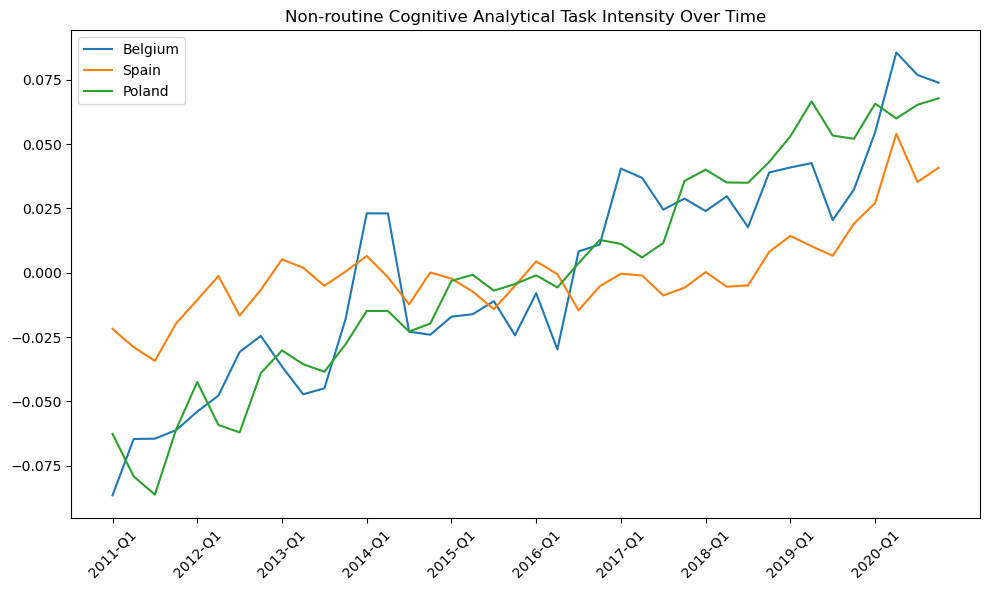

In [ ]:
# Calculate Composite NRCA and Standardize it
for country in COUNTRIES:
    # Sum the specific standardized tasks for this country
    std_cols = [f"std_{country}_{task}" for task in target_tasks]
    combined[f"{country}_NRCA"] = combined[std_cols].sum(axis=1)
    target_col = f"{country}_NRCA"
    share_col = f"share_{country}"
    
    mu = np.average(combined[target_col], weights=combined[share_col])
    sigma = np.sqrt(np.average((combined[target_col] - mu)**2, weights=combined[share_col]))
    
    combined[f"std_{country}_NRCA"] = (combined[target_col] - mu) / sigma

final_time_series = []

for country in COUNTRIES:
    # Weighted intensity calculation
    val_col = f"std_{country}_NRCA"
    share_col = f"share_{country}"
    multip_col = f"multip_{country}_NRCA"
    
    combined[multip_col] = combined[val_col] * combined[share_col]
    
    # Aggregate by TIME
    country_agg = combined.groupby("TIME")[multip_col].sum().reset_index()
    final_time_series.append(country_agg)

# Create a plot
plt.figure(figsize=(10, 6))
for i, country in enumerate(COUNTRIES):
    # Retrieve the aggregated data for this country
    data = final_time_series[i]
    plt.plot(data["TIME"], data[f"multip_{country}_NRCA"], label=country)


plt.title("Non-routine Cognitive Analytical Task Intensity Over Time")
plt.xticks(range(0, len(data), 4), data["TIME"][::4], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()